**Laboratorio de Métodos Cuantitativos Aplicados a la Gestión**

---

# **Clase 03 - Modelización de funciones económicas**

## Complemento

Este notebook se complementa con la presentación: **FuncionesEcon.pdf**

Te recomendamos leer el PDF antes de trabajar con este notebook para tener una mejor comprensión de los conceptos teóricos.

## Objetivos de la clase

- Reconocer las formas funcionales que aparecen en economía y qué comportamiento modela cada una
- Saber cuándo usar `math` y cuándo `numpy`
- Descomponer el costo en **fijo** y **variable**, y calcular costo **medio** y **marginal**
- Encontrar el **punto de equilibrio** y el nivel que **maximiza el beneficio**
- Hallar un óptimo **sin usar derivadas todavía**

---

### ¿Por qué modelizar funciones económicas?

---

En la gestión de organizaciones, tomamos decisiones todo el tiempo: ¿cuánto producir? ¿A qué precio vender? ¿Conviene expandir la capacidad? Estas preguntas no se responden con intuición sola — necesitan un **modelo**, es decir, una representación simplificada de la realidad que nos permita razonar con datos.

Un modelo matemático no pretende capturar *toda* la complejidad de un mercado o una empresa. Lo que hace es aislar las variables clave (precio, cantidad, costos) y expresar sus relaciones de forma precisa. Esa precisión es lo que nos permite:

⏩ **Cuantificar**: pasar de "si subimos el precio vamos a vender menos" a "si subimos el precio un 10%, la demanda cae en X unidades".

⏩ **Simular escenarios**: ¿qué pasa si los costos fijos aumentan? ¿Y si entra un competidor que baja los precios? El modelo nos deja explorar estas preguntas *antes* de que ocurran.

⏩ **Comunicar con evidencia**: un gráfico de punto de equilibrio le dice más a un directorio que una corazonada. Modelizar es traducir el problema de gestión a un lenguaje que permite análisis riguroso y comunicación clara.

⏩ **Automatizar el análisis**: como futuros analistas de datos, van a construir herramientas que calculen estos modelos para cientos de productos, escenarios o períodos. Entender la lógica matemática detrás es lo que les va a permitir diseñar esas herramientas correctamente — y, sobre todo, detectar cuándo los resultados no tienen sentido.

La clave es entender que **todo modelo es una simplificación útil, no una verdad absoluta**. Las funciones que vamos a ver hoy (lineales, cuadráticas, logarítmicas) son aproximaciones que funcionan bien dentro de ciertos rangos. Parte del trabajo del analista es saber cuándo el modelo aplica y cuándo hay que cambiarlo.

---

⭐ ¿Qué es una función? 📈


---


Una función f es una relación que asigna a cada elemento x de un conjunto A (dominio)
exactamente un elemento f(x) de un conjunto B (codominio).

Siendo:

⏩ Dominio: valores de x para los que f está definida"

⏩ Imagen: valores que puede tomar f(x)

En economía, usualmente trabajamos con funciones reales: $f: \mathbb{R} \to \mathbb{R}$

---



⏩ Hagamos un repaso de las funciones reales que conocemos 💪💪💪

---



In [1]:
#Paso 1 - importar las librerías que vamos a usar
import matplotlib.pyplot as plt
import numpy as np

---
## 🔧 NumPy: la librería con la que vamos a trabajar

Toda la materia trabaja con **series de datos**: precios, cantidades, costos de muchos períodos o
muchos productos. **NumPy** está hecho justo para eso: aplica una operación a **toda la serie de una
sola vez**, sin escribir un ciclo.

| Lo que escribís | Lo que hace |
|---|---|
| `np.sqrt(precios)` | La raíz de **cada** precio |
| `np.log(ventas)` | El logaritmo de **cada** venta |
| `precios * 1.21` | Le suma IVA a **todos** los precios |

Esta idea —operar sobre la serie completa— es la que vamos a usar sobre gran parte de la materia con otras librerías. A prestar atención.

In [2]:
precios = np.array([100.0, 105.0, 120.0, 180.0])

print("Precios          :", precios)
print("Raíz de cada uno :", np.sqrt(precios)) #np.algo llama una funcion determinada de matematica raiz cuadrada, logaritmos, exponentes, vectores, etc.
print("Con IVA          :", precios * 1.21)
print("Promedio         :", precios.mean())
#np.sqrt es una función de numpy que calcula la raíz cuadrada de cada elemento del array precios.
# Una sola línea opera sobre los cuatro precios: no hace falta ningún for

Precios          : [100. 105. 120. 180.]
Raíz de cada uno : [10.         10.24695077 10.95445115 13.41640786]
Con IVA          : [121.   127.05 145.2  217.8 ]
Promedio         : 126.25


### ⚠️ La trampa del `nan`

`nan` significa *not a number*. Aparece cuando una cuenta no tiene resultado real: la raíz de un
negativo, el logaritmo de cero, una división `0/0`.

**El problema no es que aparezca: es que se contagia en silencio.** Cualquier cuenta que toque un
`nan` devuelve `nan`, y el error se propaga hasta el informe final sin que nadie se entere.

In [3]:
raiz_negativa = np.sqrt(-1.0)          # no corta el programa: devuelve nan
print("np.sqrt(-1) =", raiz_negativa)

contaminado = raiz_negativa + np.array([10.0, 20.0, 30.0])
print("Y contagia todo lo que toca:", contaminado)

# Por eso conviene chequear antes de seguir
print("\n¿Hay algún nan?", np.isnan(contaminado).any())
print("Cantidad de nan  :", np.isnan(contaminado).sum())

np.sqrt(-1) = nan
Y contagia todo lo que toca: [nan nan nan]

¿Hay algún nan? True
Cantidad de nan  : 3


C:\Users\juanc\AppData\Local\Temp\ipykernel_7400\1468663770.py:1: RuntimeWarning: invalid value encountered in sqrt
  raiz_negativa = np.sqrt(-1.0)          # no corta el programa: devuelve nan


### ✅ Función lineal

---

$$f(x) = mx + b$$


---



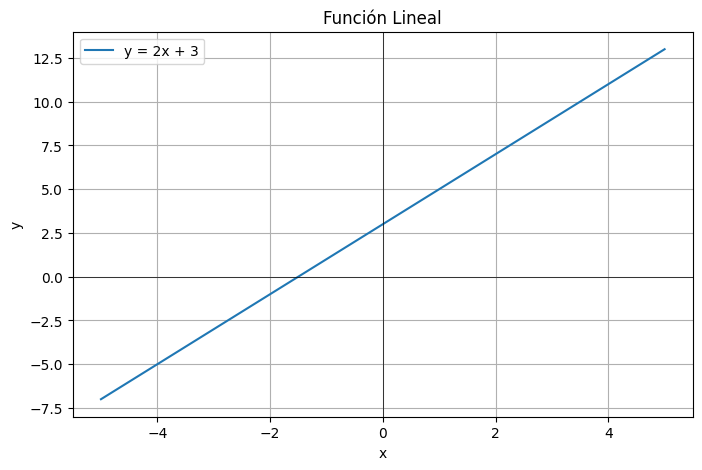

In [44]:
#Función lineal

# Establecemos los parámetros de la función
# m=pendiente ; b=ordenada al origen

m = 2    # Podemos cambiar la pendiente y ver el efecto!
b = 3    # Podemos cambiar la ordenada al origen y ver el efecto!

# Generamos puntos para graficar
x = np.linspace(-5, 5, 100) # generamos el espacio de x desde -5 hasta 5 con 100 puntos
y = m * x + b # ponemos la funcion

# Creamos el gráfico

plt.figure(figsize=(8,5))  # Define el tamaño de la figura (ancho x alto)
plt.plot(x, y, label=f'y = {m}x + {b}')  # Dibuja la línea con su ecuación como leyenda
plt.axhline(0, color='black', linewidth=0.5)  # Dibuja eje horizontal (x=0)
plt.axvline(0, color='black', linewidth=0.5)  # Dibuja eje vertical (y=0)
plt.title('Función Lineal')  # Título del gráfico
plt.xlabel('x')  # Etiqueta del eje x
plt.ylabel('y')  # Etiqueta del eje y
plt.legend()  # Muestra la leyenda (etiqueta de la línea)
plt.grid(True)  # Activa la cuadrícula
plt.show()  # Muestra el gráfico en pantalla

### ✅ Función cuadrática

---

$$f(x) = ax^2 + bx + c$$

---



Vértice de la función: (0.75; -0.125)


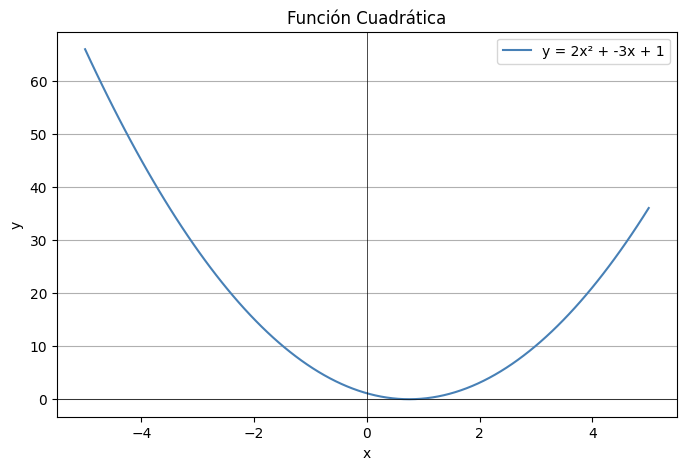

In [48]:
#Función cuadrática

#Establecemos los parámetros

a = 2    # Podemos cambiarlo y ver el efecto!
b = -3   # Podemos cambiarlo y ver el efecto!
c = 1    # Podemos cambiarlo y ver el efecto!

# Generamos puntos para graficar y repetimos el proceso para la función cuadrática
x = np.linspace(-5, 5, 100)
y = a*x**2 + b*x + c

# Bonus: podemos encontrar el vértice de la función
x_vertice = (-b/
                (2*a))
y_vertice = a*x_vertice**2 + b*x_vertice + c

print(f"Vértice de la función: ({x_vertice}; {y_vertice})")


# Creamos el gráfico
plt.figure(figsize=(8,5))
plt.plot(x, y,"#4780B6", label=f'y = {a}x² + {b}x + {c}') # Hay colores que ya están definidos como red, violet, etc. Pero también podemos personalizar mediante el código hexadecimal (https://www.reddit.com/r/ColorBlind/comments/bxpiyh/hexadecimal_color_codes_explained/?tl=es-419)
# ¿Qué pasa si escribo y, x?

# Marcamos los ejes
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)

# Agregamos detalles
plt.title('Función Cuadrática')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True, axis="y") # Sí solo quiero la grilla en un eje.
plt.show()

### ✅ Función exponencial

---
$$f(x) = a \cdot e^{bx}$$

---




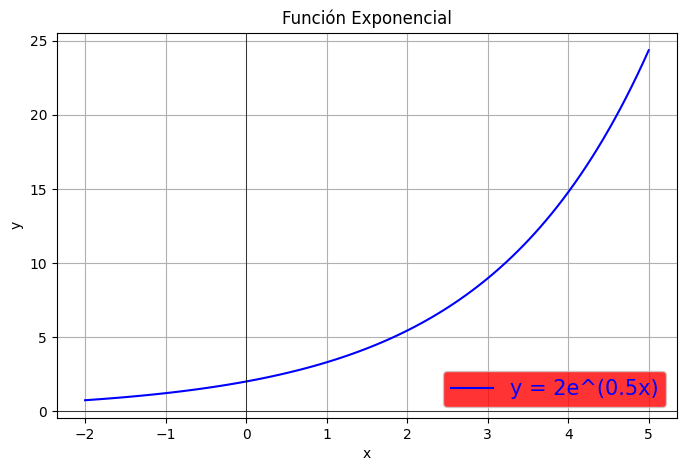

In [6]:
#Función exponencial

#Establecemos los parámetros

a = 2    # Podemos cambiarlo y ver el efecto!
b = 0.5  # Podemos cambiarlo y ver el efecto!

# Generamos puntos para graficar
x = np.linspace(-2, 5, 100)
y = a * np.exp(b * x)

# Creamos el gráfico
plt.figure(figsize=(8,5))
plt.plot(x, y,'blue', label=f'y = {a}e^({b}x)')
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.title('Función Exponencial')
plt.xlabel('x')
plt.ylabel('y')
plt.legend(fontsize=15, facecolor="red", labelcolor="blue") # A muchas de las funciones, dentro de su parentésis se pueden editar
plt.grid(True)
plt.show()

### ✅ Función logarítmica

---

$$f(x) = \ln(x)$$

---



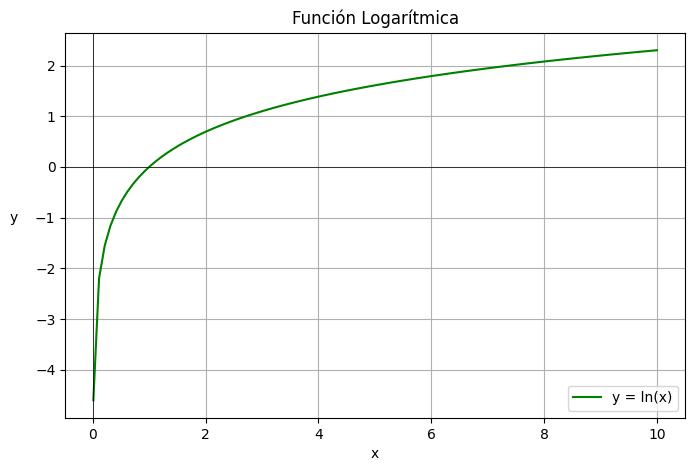

In [7]:
#Función logarítmica
# Generamos puntos para graficar
x = np.linspace(.01, 10, 100)  # Empezamos en 0.01 para evitar error. Cambiar la cantidad de puntos para observar la diferencia.
y = np.log(x)

# Creamos el gráfico
plt.figure(figsize=(8,5))
plt.plot(x, y, 'green',label='y = ln(x)')
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.title('Función Logarítmica')
plt.xlabel('x')
plt.ylabel('y', rotation=0, labelpad=15) # ¿Que cambié con esto?
plt.legend()
plt.grid(True)
plt.show()

### ✅ Función polinómica

---
$$f(x) = a_n x^n + a_{n-1} x^{n-1} + \cdots + a_2 x^2 + a_1 x + a_0$$

---




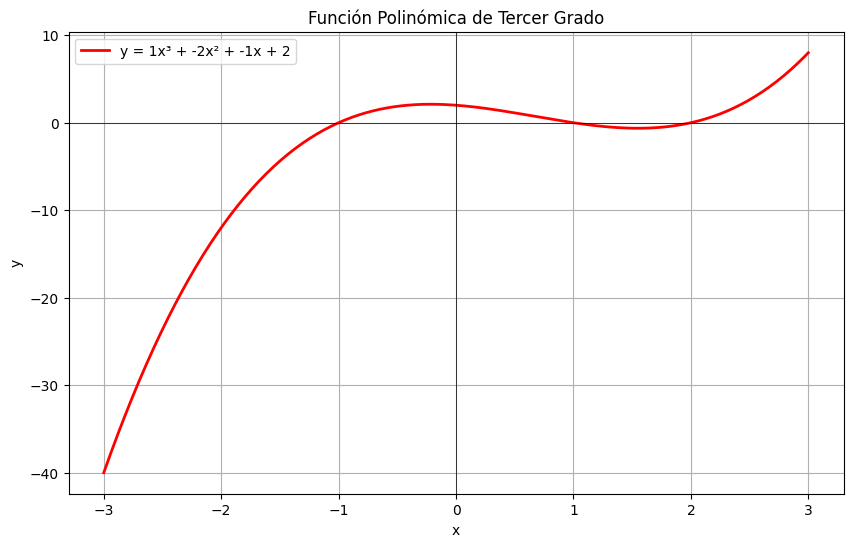

In [8]:
#Función polinómica
#Armamos un polinomio de grado 3

# Establecemos los coeficientes del polinomio (¡se pueden cambiar y ver el efecto!)
a = 1    # para x³
b = -2   # para x²
c = -1   # para x
d = 2    # término independiente

# Generamos puntos para el gráfico
x = np.linspace(-3, 3, 200)
y = a*x**3 + b*x**2 + c*x + d

# Configuramos el gráfico
plt.figure(figsize=(10,6))
plt.plot(x, y, 'red', linewidth=2, label=f'y = {a}x³ + {b}x² + {c}x + {d}')

# Marcamos los ejes
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)

# Añadimos detalles
plt.title('Función Polinómica de Tercer Grado')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

### ✅ Función módulo

---
$$f(x) = |x|$$

---




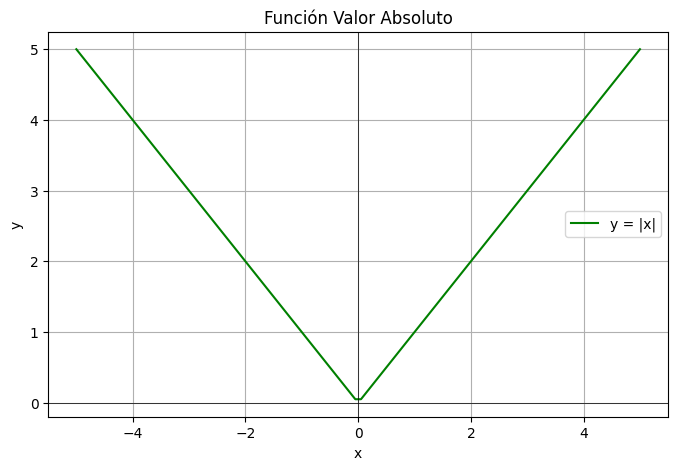

In [9]:
#Función módulo
# Generamos puntos para el gráfico

x = np.linspace(-5, 5, 100)
y = np.abs(x)

# Creamos el gráfico
plt.figure(figsize=(8,5))
plt.plot(x, y,'green', label='y = |x|')
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.title('Función Valor Absoluto')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

### ✅ Funciones Trigonométricas

---
$$f(x) = a \operatorname{sen}(b \cdot x)$$

$$f(x) = a \cos(b \cdot x)$$

---




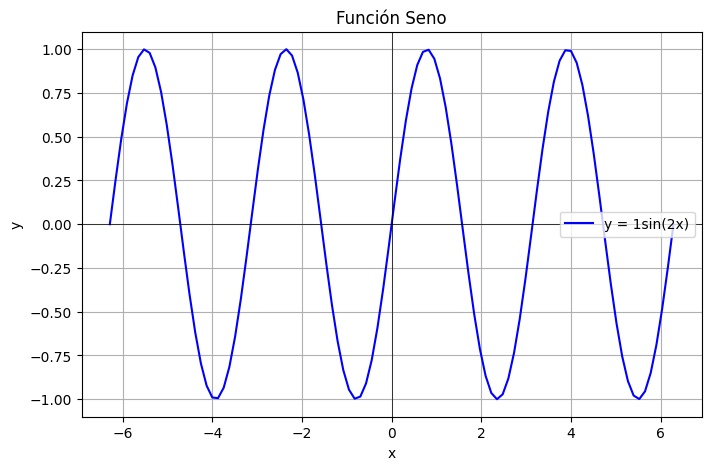

In [10]:
#Función seno
#Establecemos los parámetros (se pueden cambiar y ver el efecto!)
a=1
b=2

# Generamos puntos para el gráfico
x = np.linspace(-2*np.pi, 2*np.pi, 100)
y = a * np.sin(b*x)

#Creamos el gráfico
plt.figure(figsize=(8,5))
plt.plot(x, y,'blue', label=f'y = {a}sin({b}x)')
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.title('Función Seno')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

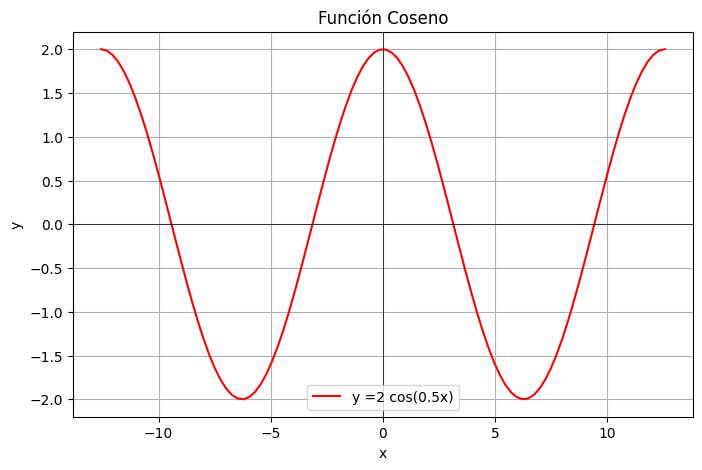

In [11]:
#Función Coseno
#Establecemos los parámetros (se pueden cambiar para ver el efecto!)

a=2
b=1/2

# Generamos puntos para el gráfico
x = np.linspace(-4*np.pi, 4*np.pi, 100)
y = a * np.cos(b*x)

#Creamos el gráfico
plt.figure(figsize=(8,5))
plt.plot(x, y,'red', label=f'y ={a} cos({b}x)')
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.title('Función Coseno')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

### ✅ Función homográfica

---
$$f(x) = \frac{ax + b}{cx + d}$$

---




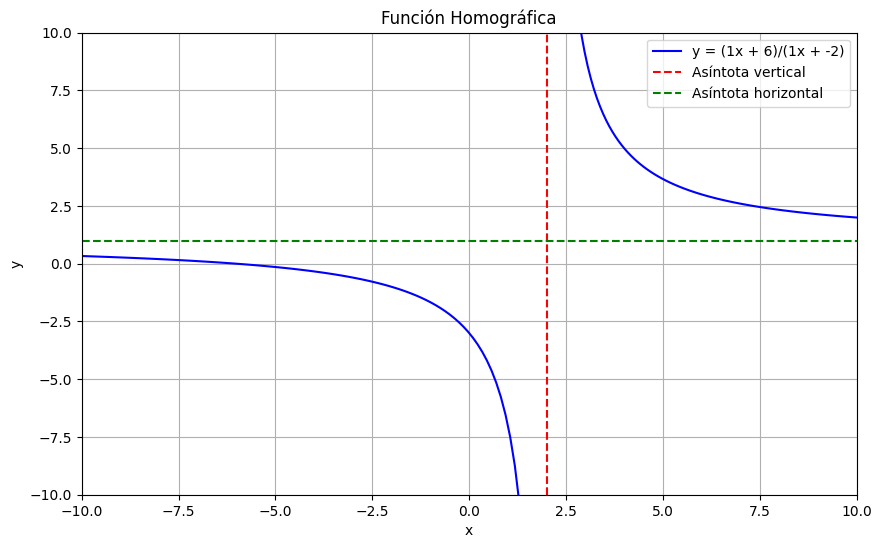

In [12]:
#Función homográfica

# Establecemos los parámetros de la función (¡se pueden cambiar para ver el efecto!)
a = 1
b = 6
c = 1
d = -2

# Calculamos dónde está la asíntota vertical
asintota_vertical = -d/c
asintota_horizontal= a/c
# Creamos puntos a izquierda y derecha de la asíntota
x_izq = np.linspace(-10, asintota_vertical - 0.1, 100)  # Evitamos la división por cero
x_der = np.linspace(asintota_vertical + 0.1, 10, 100)   # Pequeño espacio después de la asíntota

y_izq = (a*x_izq + b)/(c*x_izq + d)
y_der = (a*x_der + b)/(c*x_der + d)

# Configuramos el gráfico
plt.figure(figsize=(10,6))
plt.plot(x_izq, y_izq, color='blue', label=f'y = ({a}x + {b})/({c}x + {d})')
plt.plot(x_der, y_der, color='blue')

# Dibujamos las asíntotas
plt.axvline(asintota_vertical, color='red', linestyle='--', label='Asíntota vertical')
plt.axhline(asintota_horizontal, color='green', linestyle='--', label='Asíntota horizontal')

# Añadimos detalles
plt.title('Función Homográfica')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.xlim(-10, 10)
plt.ylim(-10, 10)
plt.show()



---
⏩ Ahora veamos las funciones económicas y apliquemos lo que sabemos!!! ✨✨✨
---






---

- **Función de demanda**: relaciona la cantidad demandada y el precio del mercado. $x = D(p)$, donde $x$ representa la cantidad que los consumidores están dispuestos a adquirir para distintos niveles o valores del precio $p$. Al estar observando desde el lado de la demanda, estamos ante una **relación inversa**. Es decir, ante aumentos en el precio, observaríamos una caída en las cantidades demandadas, y viceversa.


---



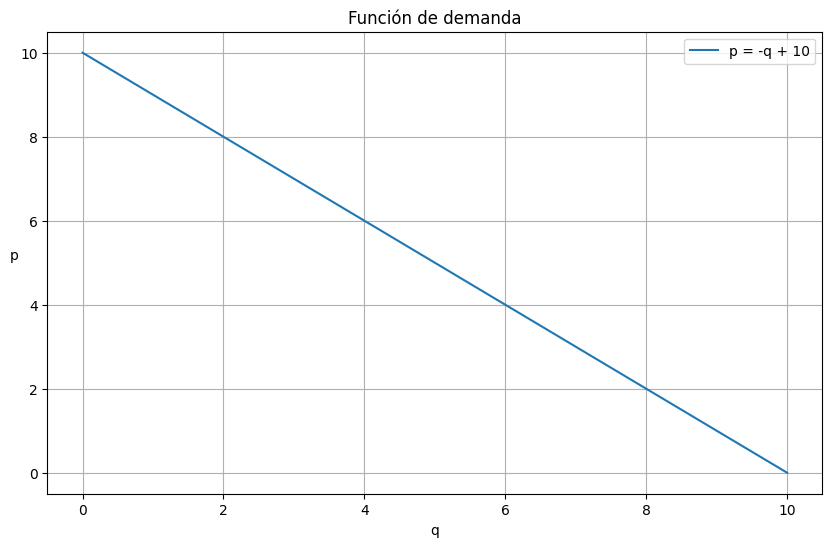

In [13]:
# Generamos 2 puntos de q entre 0 y 10 (alcanza con 2 porque la función es una recta)
q = np.linspace(0, 10, 2)
p = -q + 10  # Función de demanda: relación inversa entre precio y cantidad

#Gráfico
plt.figure(figsize=(10, 6))
plt.plot(q,p,  label="p = -q + 10")
plt.legend()
plt.title("Función de demanda")
plt.xlabel("q")
plt.ylabel("p", rotation=0)
plt.grid(True)
plt.show()

- **Función de oferta**: relaciona cantidad ofrecida y el precio. $x = Of(p)$, estableciendo las cantidades $x$ del bien considerado que los productores ofrecen para cada valor del precio. Al estar observando desde el lado de la oferta, estamos ante una **relación directa**. Es decir, ante aumentos en el precio, observaríamos un aumento en las cantidades demandadas, y viceversa.


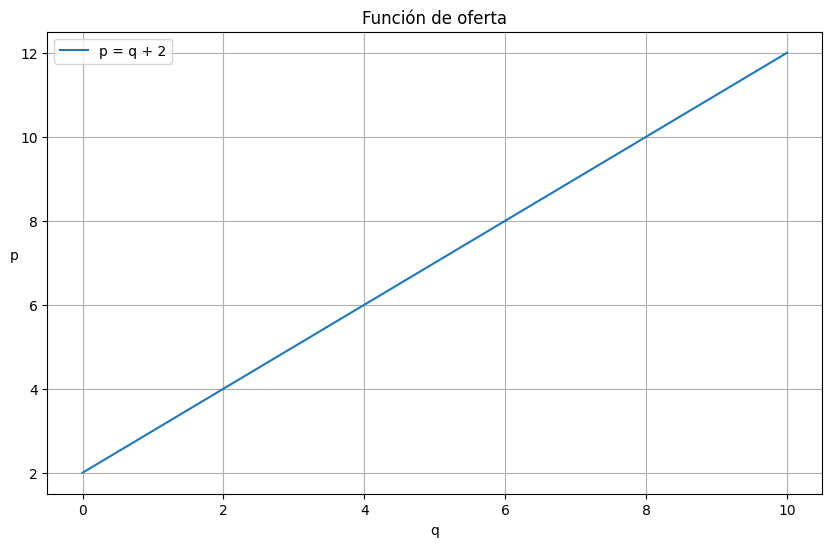

In [14]:
q= np.linspace(0, 10, 2)
p=q+2 # Función de oferta: relación directa entre precio y cantidad

#Gráfico
plt.figure(figsize=(10, 6))
plt.plot(q,p,  label="p = q + 2")
plt.legend()
plt.title("Función de oferta")
plt.xlabel("q")
plt.ylabel("p", rotation=0)
plt.grid(True)
plt.show()

Entonces, las funciones de oferta y demanda se comportan de forma contraria.

 Si las funciones de demanda u oferta están expresadas en función del precio p, habrá que hallar la función inversa.

---

Punto de Equilibrio de mercado:

Se produce equilibrio de mercado cuando la cantidad demandada de un producto es igual a la cantidad ofrecida del mismo.
El precio y la cantidad de equilibrio corresponden a las coordenadas del punto de intersección de las curvas de oferta y demanda: $D(p*) = Of(p*)$

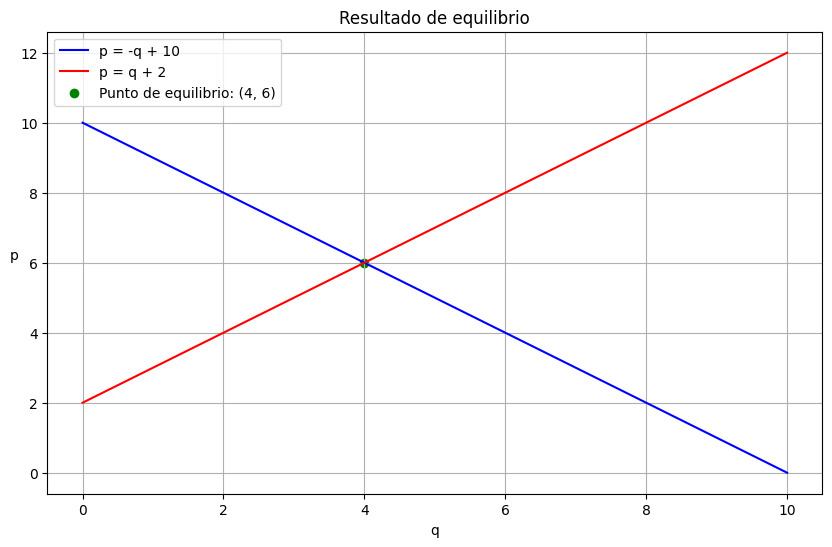

In [15]:

q_d= np.linspace(0, 10, 2)
p_d=-q_d+10
q_o= np.linspace(0, 10, 2)
p_o=q_o+2
# El punto de equilibrio se da con el precio que iguale ambas cantidades: -q_d + 10 = q_o + 2 ==> q* = 4 ==> p* = 6

q_eq= 4
p_eq= 6

#Gráfico
plt.figure(figsize=(10, 6))
plt.plot(q_d,p_d,  label="p = -q + 10", color="blue")
plt.plot(q_o,p_o,  label="p = q + 2", color="red")
plt.scatter(4, 6, color='green', label=f'Punto de equilibrio: ({q_eq}, {p_eq})') # Marcamos el punto de equilibrio con un scatter
plt.legend()
plt.title("Resultado de equilibrio")
plt.xlabel("q")
plt.ylabel("p", rotation=0)
plt.grid(True)
plt.show()

---
**Funciones de la empresa:** En una firma, hay tres formulas principales que nos permiten saber como son sus finanzas.

---

Por un lado, el ingreso, que está determimado por las ventas (precio x cantidades vendidas).


- Función de Ingreso: $I(x) = p \cdot x$


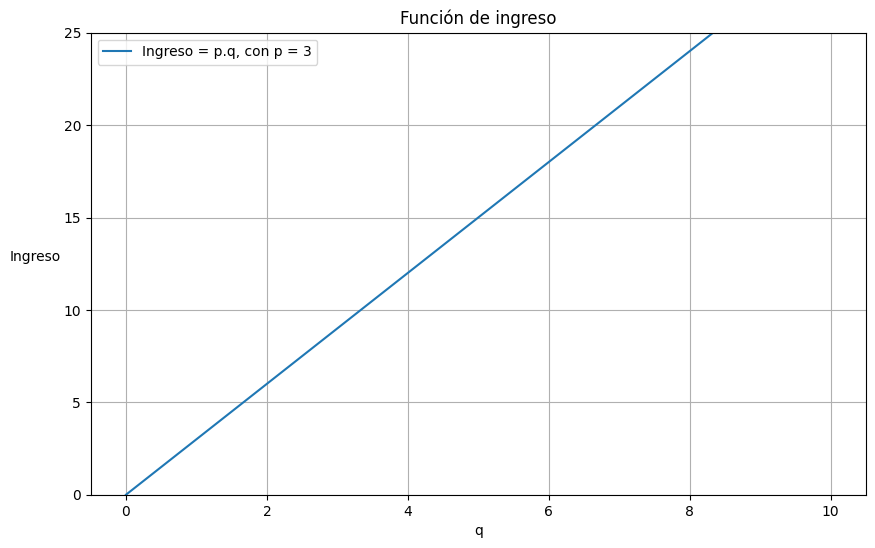

In [16]:
q = np.linspace(0, 10, 100)
p = 3  # precio constante (fijado por el mercado)
ingreso = p*q

#Gráfico
plt.figure(figsize=(10, 6))
plt.plot(q,ingreso,  label="Ingreso = p.q, con p = 3")
plt.legend()
plt.title("Función de ingreso")
plt.xlabel("q")
plt.ylabel("Ingreso", rotation=0, labelpad= 20)
plt.grid(True)
plt.ylim(0,25) # fijamos el rango del eje y para que sea comparable con el próximo gráfico
plt.show()

Por el otro, el costo de producción, que este puede estar categorizado como costo fijo (independiente de la producción), y el costo variable (depende de las cantidades producidas).

- Función de Costo: $C(x) = CV(x) + CF$



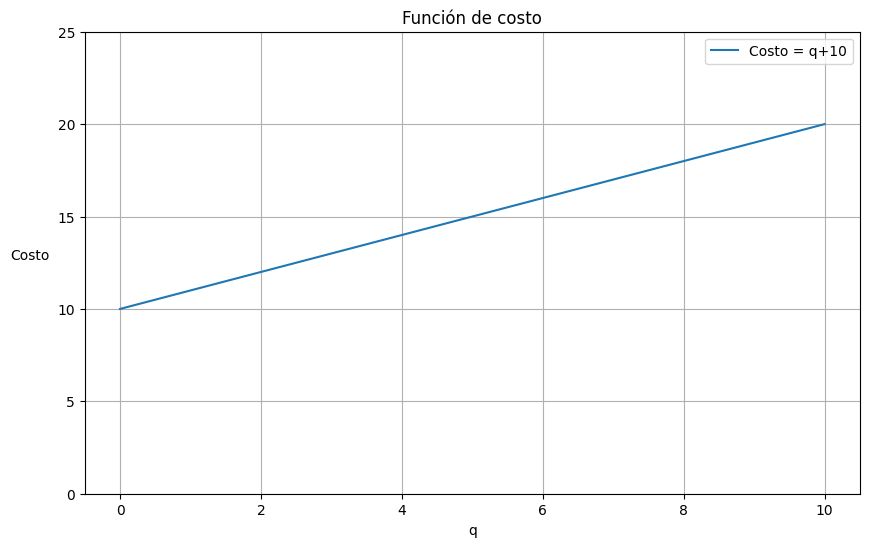

In [17]:
q = np.linspace(0, 10, 100)
c_v = 1 * q   # Costo variable: depende de la cantidad producida
c_f = 10      # Costo fijo: constante, no depende de q
costo = c_v + c_f  # Costo total = costo variable + costo fijo

#Gráfico
plt.figure(figsize=(10, 6))
plt.plot(q,costo,  label="Costo = q+10")
plt.legend()
plt.title("Función de costo")
plt.xlabel("q")
plt.ylabel("Costo", rotation=0, labelpad= 20)
plt.grid(True)
plt.ylim(0,25)
plt.show()

Por último, con la unión de las dos, obtendremos las ganancias de la empresa, es decir, la Función de Beneficio.

- Función de Beneficio: $B(x) = I(x) - C(x)$.

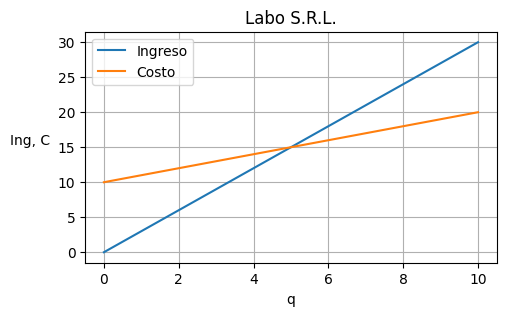

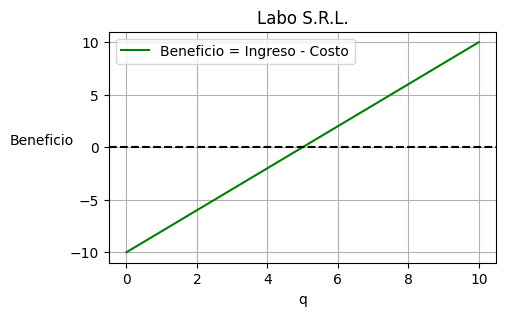

In [18]:
# Primera figura: ingreso y costo juntos, para comparar visualmente
plt.figure(1,figsize=(5.31, 3))
plt.plot(q,ingreso,  label="Ingreso")
plt.plot(q,costo,  label="Costo")
plt.legend()
plt.title("Labo S.R.L.")
plt.xlabel("q")
plt.ylabel("Ing, C", rotation=0, labelpad= 20)
plt.grid(True)

# Segunda figura: el beneficio (ingreso - costo) por separado
plt.figure(2,figsize=(5, 3))
plt.plot(q,ingreso-costo,  label="Beneficio = Ingreso - Costo", color="green")
plt.legend()
plt.title("Labo S.R.L.")
plt.xlabel("q")
plt.ylabel("Beneficio", rotation=0, labelpad= 20)
plt.axhline(0, color='black', linestyle='--', label='Beneficio nulo')
plt.grid(True)
plt.show()

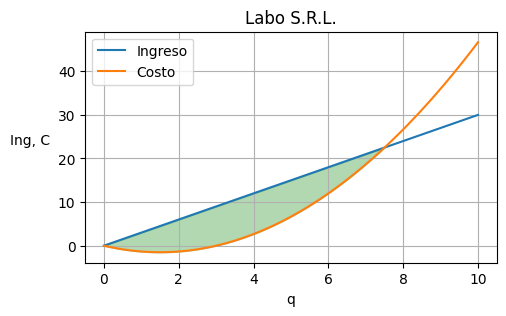

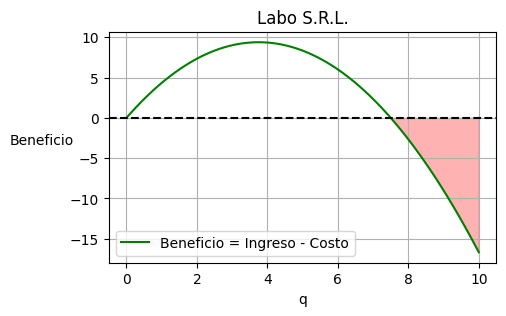

In [19]:
# Ahora el costo variable es cuadrático (no lineal), simula rendimientos decrecientes/crecientes
c_v = 2/3 * q**2 - 2*q
c_f = 0
costo = c_v + c_f
beneficio = ingreso - costo

# Primera figura: ingreso vs costo, sombreando en verde donde hay beneficio positivo
plt.figure(1, figsize=(5.31, 3))
plt.plot(q, ingreso, label="Ingreso")
plt.plot(q, costo, label="Costo")

# Rellenamos el área entre ingreso y costo, solo donde el beneficio es positivo (ingreso > costo)
plt.fill_between(q, ingreso, costo, where=(beneficio >= 0), color='green', alpha=0.3, interpolate=True)

plt.legend()
plt.title("Labo S.R.L.")
plt.xlabel("q")
plt.ylabel("Ing, C", rotation=0, labelpad=20)
plt.grid(True)

# Segunda figura: beneficio, sombreando en rojo la zona de pérdida (beneficio negativo)
plt.figure(2, figsize=(5, 3))
plt.plot(q, ingreso - costo, label="Beneficio = Ingreso - Costo", color="green")
plt.fill_between(q, beneficio, 0, where=(beneficio < 0), color='red', alpha=0.3, interpolate=True)
plt.legend()
plt.title("Labo S.R.L.")
plt.xlabel("q")
plt.ylabel("Beneficio", rotation=0, labelpad=20)
plt.axhline(0, color='black', linestyle='--', label='Beneficio nulo')
plt.grid(True)
plt.show()


**PARA PENSAR:**
---


---

¿Qué plan de negocios implica cada uno de los anteriores gráficos de beneficio?




---



---


### ✅ Vamos a resolver algunos problemas 💪💪💪

---



---



⏩ Cuál es la ecuación de oferta, **supuesta lineal**, en el mercado de CDs si cuando el precio es de
\$30 hay disponibles 35 CDs de un tipo dado y cuando el precio es de \$35 hay disponibles 50?

La ecuación de oferta es: p = 0.33x + 18.33

Verificación:
Cuando x = 35, p = 30 (debería ser 30)
Cuando x = 50, p = 35 (debería ser 35)


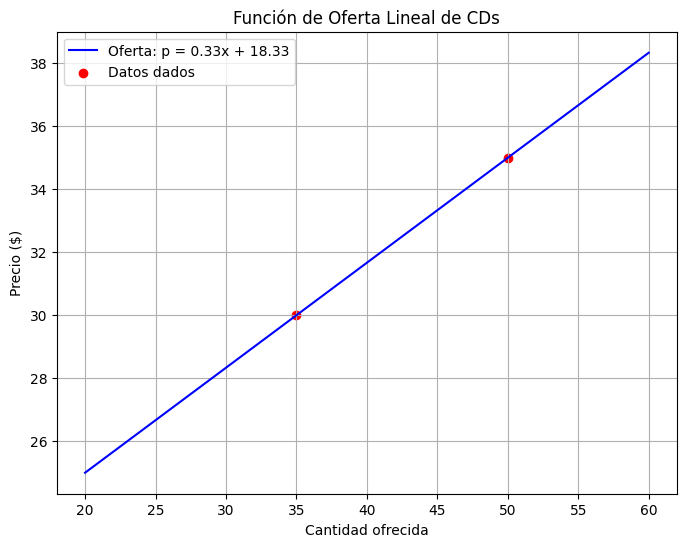

In [20]:
#Paso 1
#Planteamos los datos del problema
x1, p1 = 35, 30  # Cuando la cantidad ofertada es 35, el precio es $30
x2, p2 = 50, 35  # Cuando la cantidad ofertada es 50, el precio es $35

#Paso 2
#Calculamos la pendiente (m)
m = (p2 - p1) / (x2 - x1)

#Calculamos la ordenada al origen (b) sabiendo p=m*x+b, y seleccionando uno de los puntos dados
b = p1 - m * x1

#Paso 3
#vemos la ecuación de la recta
print(f"La ecuación de oferta es: p = {m:.2f}x + {b:.2f}")

#Verificamos para ambos puntos
print(f"\nVerificación:") # "\n..." genera un salto de renglón
print(f"Cuando x = {x1}, p = {m*x1 + b:.0f} (debería ser {p1})")
print(f"Cuando x = {x2}, p = {m*x2 + b:.0f} (debería ser {p2})")

#Paso 4
#Hacemos el gráfico
x = np.linspace(20, 60, 100)  # Rango de cantidades para graficar
p = m * x + b

plt.figure(figsize=(8, 6))
plt.plot(x, p, 'blue', label=f'Oferta: p = {m:.2f}x + {b:.2f}')
plt.scatter([x1, x2], [p1, p2], color='red', label='Datos dados') # Resalto los puntos que tenemos en nuestra muestra
plt.title('Función de Oferta Lineal de CDs')
plt.xlabel('Cantidad ofrecida')
plt.ylabel('Precio ($)')
plt.legend()
plt.grid(True)
plt.show()



---


⏩ La curva de demanda para un artículo es:

$$4x + p - 40 = 0$$
Donde x representa la cantidad demandada y p el precio.

---

a) Calcular la cantidad demandada para $p=4$  y $p=24$

b) Hallar el precio si la cantidad demandada es $x=1$ y $x=5$

c) ¿Cuál es el mayor precio que se pagaría por dicho artículo?

d) ¿Qué cantidad se demandaría si el artículo fuera gratis?

e) Grafique la curva de demanda

---




In [21]:
#Parte a)

# Definimos la ecuación de demanda: 4x + p - 40 = 0
# Podemos reescribirla como: p = -4x + 40

#Calculamos la cantidad demandada para p = 4 y p = 24
#Para eso podemos armar esta función y usarla para definir x a partir de un p

def cantidad_demandada(p):
    """Calcula x (cantidad demandada) dado p (precio)"""
    return (40 - p)/4

p1 = 4
p2 = 24

# Llamo a la función para definir las cantidades demandadas de cada precio:
x1 = cantidad_demandada(p1)
x2 = cantidad_demandada(p2)

print("a) Cantidad demandada:")
print(f" - Para un precio de ${p1}, la cantidad demandada es {x1} unidades")
print(f" - Para un precio de ${p2}, la cantidad demandada es {x2} unidades\n")

a) Cantidad demandada:
 - Para un precio de $4, la cantidad demandada es 9.0 unidades
 - Para un precio de $24, la cantidad demandada es 4.0 unidades



In [22]:
# Parte b)

# Hallamos el precio para x = 1 y x = 5
# Para eso podemos armar esta función y usarla para definir p a partir de un x

def precio_demanda(x):
    """Calcula p (precio) dado x (cantidad demandada)"""
    return -4*x + 40

x3 = 1
x4 = 5

#Llamo a la función de precios:
p3 = precio_demanda(x3)
p4 = precio_demanda(x4)

print("b) Precio para cantidades demandadas:")
print(f" - Para una cantidad demandada de {x3} unidad, el precio es ${p3}")
print(f" - Para una cantidad demandada de {x4} unidades, el precio es ${p4}\n")

b) Precio para cantidades demandadas:
 - Para una cantidad demandada de 1 unidad, el precio es $36
 - Para una cantidad demandada de 5 unidades, el precio es $20



In [23]:
# Parte c)
# Calculamos el mayor precio que se pagaría
# Notar que coincide con la intersección de la curva con el eje de las ordenadas
# o sea, el mayor precio ocurre cuando x = 0

#Para calcularlo usamos la función que creamos anteriormente

p_max = precio_demanda(0)
print(f"c) El mayor precio que se pagaría es: ${p_max}")

c) El mayor precio que se pagaría es: $40


In [24]:
#Parte d)
#Calculamos la cantidad demandada si el artículo es gratis (p = 0)
#Notar que coincide con la intersección de la curva con el eje de las abscisas

#Para calcularlo usamos la función que creamos anteriormente

x_gratis = cantidad_demandada(0)
print(f"d) Si el artículo fuera gratis (p = $0), se demandarían {x_gratis} unidades")

d) Si el artículo fuera gratis (p = $0), se demandarían 10.0 unidades


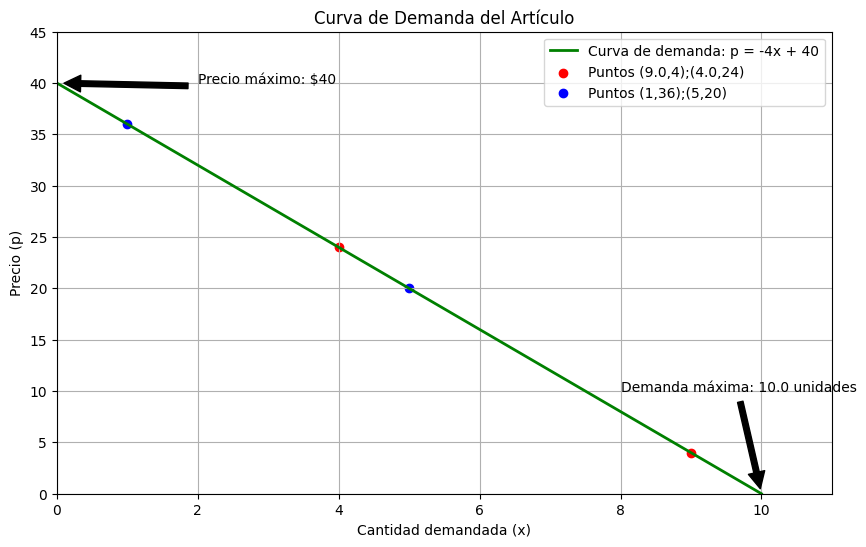

In [25]:
# Parte e)
# Graficamos la curva de demanda

valores_x = np.linspace(0, 10, 100)  # Marcamos el rango de unidades (0 a 10 unidades)
valores_p = -4*valores_x + 40

plt.figure(figsize=(10, 6))
plt.plot(valores_x, valores_p, 'green', linewidth=2, label='Curva de demanda: p = -4x + 40')

# Marcamos los puntos de las partes a y b
plt.scatter([x1, x2], [p1, p2], color='red', label=f'Puntos ({x1},{p1});({x2},{p2})')
plt.scatter([x3, x4], [p3, p4], color='blue', label=f'Puntos ({x3},{p3});({x4},{p4})')

# Agregamos los detalles del gráfico
plt.title('Curva de Demanda del Artículo')
plt.xlabel('Cantidad demandada (x)')
plt.ylabel('Precio (p)')
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.grid(True)
plt.legend()
plt.xlim(0, 11)
plt.ylim(0, 45)

# Agregamos anotaciones sobre el gráfico
plt.annotate(f'Precio máximo: ${p_max}', xy=(0, p_max), xytext=(2, 40),
             arrowprops=dict(facecolor='black', shrink=0.05))
plt.annotate(f'Demanda máxima: {x_gratis} unidades', xy=(x_gratis, 0), xytext=(8, 10),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.show()



---


⏩ Dado un producto cuya ley de costo total está dada por:

**Función de Costo Total:**

$$C(x) = \frac{1}{10}x^2 - 10x + 600$$


 **Función de Demanda:**
  
$$x = -10p + 600$$
   
   
   Donde:
   - $x$ = cantidad de unidades
   - $p$ = precio por unidad (\$)
   -  C(x) = costo total (\$)

**Se pide:**

a) Hallar la ley de **beneficio total**  
b) Hallar la ley de **beneficio medio**  
c) Calcular el beneficio total y medio para una demanda de **200 unidades**

---



In [26]:
#Paso 1
#definimos las funciones de costo total, demanda , demanda inversa, ingreso

def costo_total(x):
    return (1/10) * x**2 - 10*x + 600

def demanda(p):
    return -10*p + 600

def demanda_inversa (x): # Esto es equivalente al precio.
    return (600-x)/10

def ingreso_total(x):
    return demanda_inversa(x) * x


In [27]:
#Paso 2
#Armamos la función de beneficio total y beneficio medio

# a) Ley de beneficio total
def beneficio_total(x):
    return ingreso_total(x) - costo_total(x)

# b) Ley de beneficio medio
def beneficio_medio(x):
    return beneficio_total(x) / x

In [28]:
#Paso 3
#Calculamos el beneficio total y medio para una producción de 200 unidades

x_ejemplo = 200
b_total_ejemplo = beneficio_total(x_ejemplo)
b_medio_ejemplo = beneficio_medio(x_ejemplo)

# Mostramos resultados
print("=== RESULTADOS ===")
print(f"El Beneficio medio para una producción de {x_ejemplo} unidades es: {b_medio_ejemplo}")
print(f"El Beneficio total para una producción de {x_ejemplo} unidades es: {b_total_ejemplo}")

=== RESULTADOS ===
El Beneficio medio para una producción de 200 unidades es: 27.0
El Beneficio total para una producción de 200 unidades es: 5400.0


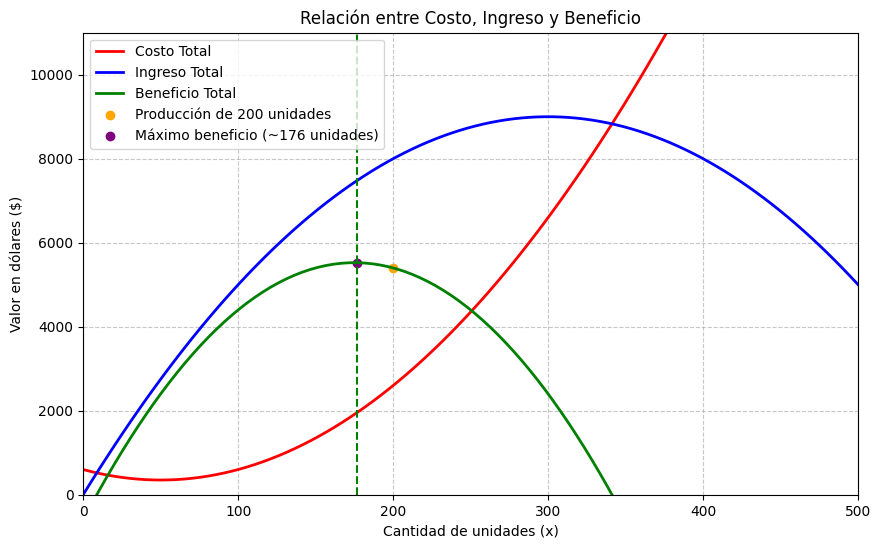

In [29]:
#Paso 4
#Graficamos las curvas de Ingreso, Costo y Beneficio

#Establecemos un rango de cantidades (0 a 500 unidades)
x = np.linspace(0, 500, 100)

# Configuramos el gráfico
plt.figure(figsize=(10, 6))

# Dibujamos las tres curvas principales
plt.plot(x, costo_total(x), 'red', linewidth=2, label='Costo Total')
plt.plot(x, ingreso_total(x), 'blue', linewidth=2, label='Ingreso Total')
plt.plot(x, beneficio_total(x), 'green', linewidth=2, label='Beneficio Total')

#Marcamos el beneficio total de producir las 200 unidades del ejemplo
plt.scatter([x_ejemplo], [b_total_ejemplo], color='orange', label=f'Producción de {x_ejemplo} unidades')

# Marcamos el punto de beneficio máximo
benef_max = x[np.argmax(beneficio_total(x))]
plt.scatter(benef_max, beneficio_total(benef_max), color='purple',
            label=f'Máximo beneficio (~{int(benef_max)} unidades)')
plt.axvline(benef_max, color='green', linestyle='--')

#Agregamos los detalles del gráfico
plt.title('Relación entre Costo, Ingreso y Beneficio')
plt.xlabel('Cantidad de unidades (x)')
plt.ylabel('Valor en dólares ($)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)



# Ajustamos los límites de los ejes
plt.xlim(0, 500)
plt.ylim(0, 11000)

plt.show()



---
⏩ En una fábrica cuyo costo es lineal, el costo fijo es \$800.
Se sabe, además, que para producir 100 unidades el costo total es de $1400.

Se pide:

a) Hallar las funciones de costo total y costo medio.

b) Hallar costo total y medio para 200 y 1000 unidades.

c) Si el productor vende el producto a un precio unitario de $10, ¿para qué nivel de producción cubre los costos totales suponiendo que venda todo lo que produce?

d) Graficar lasfunciones de ingreso,costo y beneficio.
Sacar conclusiones.

---




In [30]:
#Paso 1
#Con los datos del problema buscamos la función de costo total, el cual es lineal

x0= 0
c0=800
x1=100
c1=1400

#Calculamos la pendiente (m)
m = (c1 - c0) / (x1 - x0)

#Calculamos la ordenada al origen (b) sabiendo c=m*x+b, y seleccionando uno de los puntos dados
b = c1 - m * x1

#vemos la ecuación de la recta de costo total y deducimos la función de costo medio
print(f"La función de costo total es: C(x) = {m} x + {b}")
print(f"La función de costo medio es: Cmed(x) = ({m} x + {b})/x")

La función de costo total es: C(x) = 6.0 x + 800.0
La función de costo medio es: Cmed(x) = (6.0 x + 800.0)/x


In [31]:
#Paso 2
#Armamos las funciones de costo total y medio para poder utilizarlas luego
#⚠️ NOTA: redefinimos costo_total() y costo_medio() para este ejercicio.
#   Las definiciones del ejercicio anterior ya no estarán disponibles.

def costo_total(x):
    return m * x + b

def costo_medio(x):
    return costo_total(x) / x

#Mostramos los costos total y medios para 200 y 1000 unidades
print("=== RESULTADOS ===")
print(f"Para una producción de 200 unidades, el costo total es: {costo_total(200)}")
print(f"Para una producción de 200 unidades, el costo medio es: {costo_medio(200)}")

print(f"Para una producción de 1000 unidades, el costo total es: {costo_total(1000)}")
print(f"Para una producción de 1000 unidades, el costo medio es: {costo_medio(1000)}")


=== RESULTADOS ===
Para una producción de 200 unidades, el costo total es: 2000.0
Para una producción de 200 unidades, el costo medio es: 10.0
Para una producción de 1000 unidades, el costo total es: 6800.0
Para una producción de 1000 unidades, el costo medio es: 6.8


In [32]:
#Paso 3
#Se debe responder:
#Si el productor vende el producto a un precio unitario de $10,
#¿para qué nivel de producción cubre los costos totales suponiendo que venda todo lo que produce?
#En competencia perfecta, el equilibrio se dá I(X)=C(X)
#Entonces ya podemos armar las función de ingreso y beneficio

#⚠️ NOTA: redefinimos ingreso() y beneficio() para este ejercicio.

def ingreso(x):
    return 10 * x

def beneficio(x):
    return ingreso(x) - costo_total(x)

#Buscamos el punto de equilibrio
#A partir de que sabemos
costo_fijo = 800
costo_variable_unitario = 6
precio_venta = 10
#y se debe satisfacer :  10 x = 6 x + 800

punto_de_equilibrio= costo_fijo / (precio_venta - costo_variable_unitario)

print(f"El punto de equilibrio se alcanza produciendo {punto_de_equilibrio} unidades")
print(f"Verificación:")
print(f"Costo total en equilibrio: ${costo_total(punto_de_equilibrio)}")
print(f"Ingreso en equilibrio: ${ingreso(punto_de_equilibrio)}")

El punto de equilibrio se alcanza produciendo 200.0 unidades
Verificación:
Costo total en equilibrio: $2000.0
Ingreso en equilibrio: $2000.0


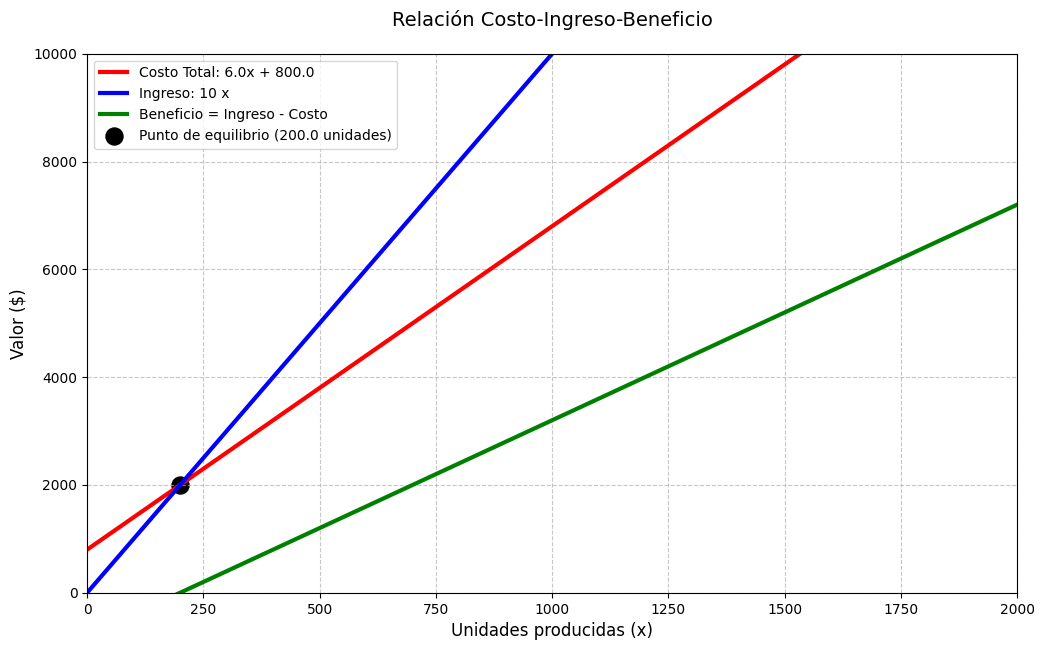


CONCLUSIONES:
La empresa necesita producir aproximadamente 200 unidades para cubrir costos
El beneficio aumenta constantemente después del punto de equilibrio
La pendiente del ingreso es mayor que la del costo, lo que asegura rentabilidad a partir de una escala de producción mínima


In [33]:
#Paso 4
#Graficamos las funciones de I(x),C(x) y B(x)

#Establecemos el rango de producción para graficar (0 a 2000 unidades)
x = np.linspace(0, 2000, 300)

# Configuramos el gráfico
plt.figure(figsize=(12, 7))

# Graficamos las tres funciones
plt.plot(x, costo_total(x), 'red', linewidth=3, label=f'Costo Total: {m}x + {b}')
plt.plot(x, ingreso(x), 'blue', linewidth=3, label=f'Ingreso: {precio_venta} x')
plt.plot(x, beneficio(x), 'green', linewidth=3, label='Beneficio = Ingreso - Costo')

# Marcamos el punto de equilibrio
plt.scatter(punto_de_equilibrio, ingreso(punto_de_equilibrio), color='black', s=150,
            label=f'Punto de equilibrio ({punto_de_equilibrio} unidades)')


# Agregamos detalles al gráfico
plt.title('Relación Costo-Ingreso-Beneficio', pad=20, fontsize=14)
plt.xlabel('Unidades producidas (x)', fontsize=12)
plt.ylabel('Valor ($)', fontsize=12)
plt.legend(fontsize=10, loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)

# Ajustamos los límites para mejor visualización
plt.xlim(0, 2000)
plt.ylim(0, 10000)

plt.show()



print("\nCONCLUSIONES:")

print("La empresa necesita producir aproximadamente", round(punto_de_equilibrio), "unidades para cubrir costos")
print("El beneficio aumenta constantemente después del punto de equilibrio")
print("La pendiente del ingreso es mayor que la del costo, lo que asegura rentabilidad a partir de una escala de producción mínima")



---


⏩ La ecuación de demanda de cierto artículo está dada por:

$$10p + x = 300$$

y la función de Costo es:

$$C(x) = 100 \ln(x+1) + 2x + 200$$


---
Se pide:

a) Armar las funciones de ingreso, costo total, costo medio, beneficio.

b) Calcular el ingreso, costo y beneficio de producir 100 unidades

c) Graficar las funciones de ingreso, costo y beneficio y sacar conclusiones

---




In [34]:
#Paso 1
#Armamos las funciones

def nueva_demanda_inversa(x):
    return (300-x)/10

def nuevo_ingreso(x):
    return nueva_demanda_inversa(x) * x

def nuevo_costo_total(x):
    return 100 * np.log(x+1)+2*x+200

def nuevo_costo_medio(x):
    return nuevo_costo_total(x)/x

def nuevo_beneficio(x):
    return nuevo_ingreso(x) - nuevo_costo_total(x)

In [35]:
#Paso 2
# Utilizar las funciones para calcular su resultado para una producción de 100 unidades

x_produccion = 100

print("=== RESULTADOS ===")

print(f"El Ingreso para una producción de {x_produccion} es de ${nuevo_ingreso(x_produccion)}")
print(f"El Costo Total para una producción de {x_produccion} es de ${nuevo_costo_total(x_produccion)}")
print(f"El Costo Medio para una producción de {x_produccion} es de ${nuevo_costo_medio(x_produccion)}")
print(f"El Beneficio para una producción de {x_produccion} es de ${nuevo_beneficio(x_produccion)}")

=== RESULTADOS ===
El Ingreso para una producción de 100 es de $2000.0
El Costo Total para una producción de 100 es de $861.5120516841259
El Costo Medio para una producción de 100 es de $8.615120516841259
El Beneficio para una producción de 100 es de $1138.487948315874


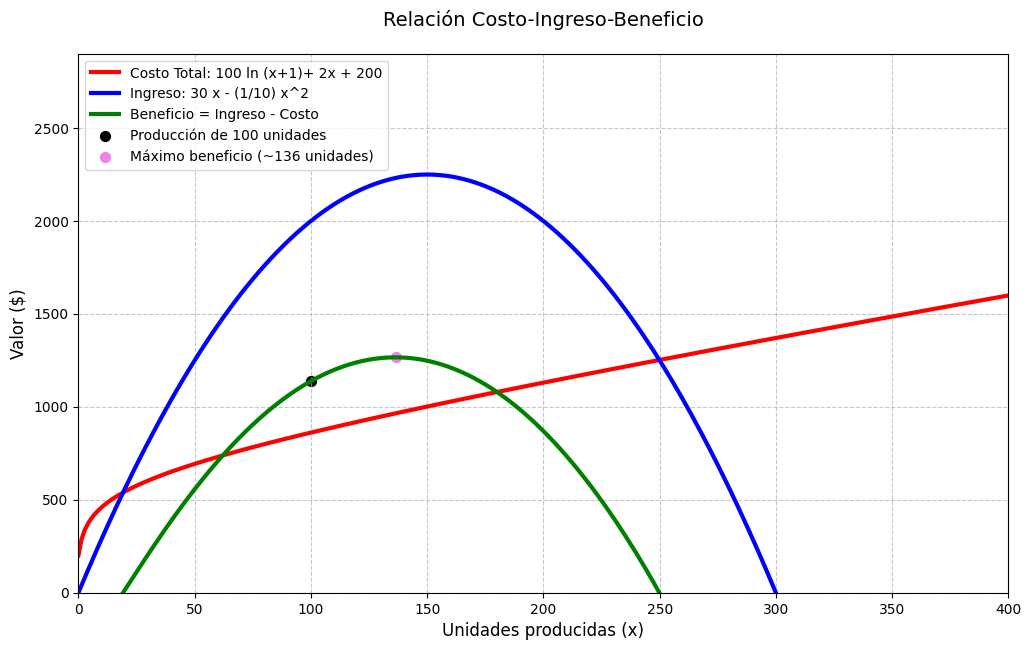

In [36]:
#Paso 3
#Graficamos las funciones de ingreso, costo, beneficio

# Establecemos un rango de producción para graficar (0 a 350 unidades)
x = np.linspace(0, 400, 300)

# Configuramos el gráfico
plt.figure(figsize=(12, 7))

# Graficamos las funciones
plt.plot(x, nuevo_costo_total(x), 'red', linewidth=3, label='Costo Total: 100 ln (x+1)+ 2x + 200')
plt.plot(x, nuevo_ingreso(x), 'blue', linewidth=3, label='Ingreso: 30 x - (1/10) x^2')
plt.plot(x, nuevo_beneficio(x), 'green', linewidth=3, label='Beneficio = Ingreso - Costo')

#Marcamos el beneficio total de producir las 100 unidades
plt.scatter([x_produccion], [nuevo_beneficio(x_produccion)], color='black',s=50, label=f'Producción de {x_produccion} unidades')

# Marcamos el punto de beneficio máximo
benef_max = x[np.argmax(nuevo_beneficio(x))]
plt.scatter(benef_max, nuevo_beneficio(benef_max), color='violet',s=50,
            label=f'Máximo beneficio (~{int(benef_max)} unidades)')


# Agregamos detalles al gráfico
plt.title('Relación Costo-Ingreso-Beneficio', pad=20, fontsize=14)
plt.xlabel('Unidades producidas (x)', fontsize=12)
plt.ylabel('Valor ($)', fontsize=12)
plt.legend(fontsize=10, loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)

# Ajustamos los límites de los ejes
plt.xlim(0, 400)
plt.ylim(0, 2900)

plt.show()





---
## 💰 Costo fijo, variable, medio y marginal

Toda función de costo se parte en dos:

$$C(q) = \underbrace{CF}_{\text{no depende de } q} + \underbrace{CV(q)}_{\text{crece con } q}$$

Y de ahí salen las dos medidas que usa gestión para decidir:

| Medida | Fórmula | Qué responde |
|---|---|---|
| **Costo medio** | $CMe(q) = C(q)/q$ | ¿Cuánto me cuesta *cada* unidad? |
| **Costo marginal** | $CMg(q) \approx C(q+1) - C(q)$ | ¿Cuánto me cuesta **la próxima** unidad? |

> 🎯 **La distinción es la que define el precio.** El costo medio sirve para saber si el negocio
> cierra; el marginal, para decidir si conviene producir una unidad más. **Son números distintos y
> confundirlos sale caro.**

In [37]:
COSTO_FIJO = 4_000_000           # alquiler, sueldos de estructura: se paga aunque no se produzca

def costo_total(q):
    """Costo de producir q unidades."""
    return COSTO_FIJO + 18_000 * q + 4 * q**2      # fijo + variable lineal + ineficiencia creciente

def costo_medio(q):
    return costo_total(q) / q                   # Observar que para que el beneficio sea nulo, el costo medio es igual al precio, Para que sea beneficio positivo, el p > CMe, y viceversa.

def costo_marginal(q):
    """Lo que cuesta la unidad número q+1 (aproximación por diferencia)."""
    return costo_total(q + 1) - costo_total(q)

for q in [100, 500, 1000, 1500]:
    print(f"q={q:>5} | Total ${costo_total(q):>12,.0f} | Medio ${costo_medio(q):>8,.0f} | Marginal ${costo_marginal(q):>8,.0f}")

q=  100 | Total $   5,840,000 | Medio $  58,400 | Marginal $  18,804
q=  500 | Total $  14,000,000 | Medio $  28,000 | Marginal $  22,004
q= 1000 | Total $  26,000,000 | Medio $  26,000 | Marginal $  26,004
q= 1500 | Total $  40,000,000 | Medio $  26,667 | Marginal $  30,004


Fijate el patrón: **el costo medio primero baja y después sube.**

Baja porque el costo fijo se reparte entre más unidades (las famosas *economías de escala*), y
después sube porque la ineficiencia creciente le gana. El punto más bajo de esa curva es la escala
más eficiente de la planta.

## ✋ Preguntas disparadoras

---
✅ 1.
¿Qué interpretación se podría dar a la curva de ingreso? ¿Qué implica esto sobre el precio y la demanda?

✅ 2. ¿Cómo influye la función logarítmica en los costos?

✅ 3. ¿Qué representa el punto donde el beneficio alcanza su valor máximo? ¿Por qué disminuye después de ese punto?

✅ 4. Sobre el Punto de Producción Actual (100 unidades)
 ¿La empresa está obteniendo ganancias o pérdidas en ese nivel?


✅ 5. Sobre el Punto de Máximo Beneficio
¿Por qué el beneficio máximo no ocurre al mismo nivel de producción donde el ingreso es máximo?

✅ 6. ¿Qué pasaría si la empresa decidiera producir más allá del punto de beneficio máximo? ¿Sería rentable?

✅ 7.
¿En qué nivel de producción el ingreso iguala al costo total? ¿Cómo se identifica en el gráfico?

✅ 8.
Si la capacidad máxima de producción fuera 300 unidades, ¿convendría alcanzarla? ¿Por qué?

✅ 9. ¿Qué pasaría si el precio de venta bajara un 20%? ¿Cómo cambiarían las curvas de ingreso y beneficio?

✅ 10.
Si fueras el gerente de producción:
¿Qué decisiones de producción tomarías?
¿Qué factores (mercado, competencia, costos) podrían hacer que este análisis cambie?

---






---
# 📝 Ejercicios

Los primeros cuatro son de práctica directa: cada uno entrena **una** cosa. El quinto es
**integrador** y se parece a lo que te vas a encontrar en el parcial.

> 💡 Trabajá siempre con NumPy y graficá lo que puedas: **el gráfico es la forma más rápida de
> darte cuenta de que un resultado no cierra.**

### ✅ Ejercicio 1 — Función lineal de costos

Una imprenta tiene un **costo fijo** mensual de \$ 850.000 (alquiler y sueldos) y un **costo
variable** de \$ 1.200 por cada folleto que produce.

1. Escribí la función de costo total $C(q)$.
2. Calculá el costo de producir 0, 500 y 2.000 folletos.
3. Graficá la función entre 0 y 3.000 unidades.
4. ¿Qué representa la **ordenada al origen** en este caso? ¿Y la **pendiente**?

In [38]:
import numpy as np
import matplotlib.pyplot as plt

COSTO_FIJO = 850_000
COSTO_VARIABLE = 1_200

def costo_total_imprenta(q):
    # Completá la fórmula:
    pass

# Tu código acá

### ✅ Ejercicio 2 — Demanda e ingreso

La demanda de un producto se estima como $p(q) = 5.000 - 2q$, donde $p$ es el precio y $q$ la
cantidad vendida.

1. Escribí la función de **ingreso total** $I(q) = p(q) \cdot q$. ¿Qué tipo de función queda?
2. Graficala entre 0 y 2.500 unidades.
3. ¿A qué cantidad el ingreso es **máximo**? Encontralo con `np.argmax`.
4. ¿Por qué el ingreso **cae** después de ese punto, si estamos vendiendo más unidades?

In [39]:
# Tu código acá

### ✅ Ejercicio 3 — Costo medio y costo marginal

Usando la función de costo del **Ejercicio 1**:

1. Calculá el **costo medio** para 100, 500, 1.000 y 2.000 folletos.
2. Calculá el **costo marginal** en esos mismos niveles.
3. ¿Por qué el costo medio **baja** a medida que se produce más, mientras el marginal se queda quieto?
4. ¿Qué pasaría con el costo medio si el alquiler subiera a \$ 1.200.000?

In [40]:
# Tu código acá

### ✅ Ejercicio 4 — Leer un gráfico

Graficá en un mismo par de ejes:

- $I(q) = 5.000q - 2q^2$
- $C(q) = 850.000 + 1.200q$

Y respondé, **mirando el gráfico**:

1. ¿En qué zona la empresa **pierde** plata? ¿En cuál gana?
2. ¿Cuántos puntos de cruce hay entre ingreso y costo? ¿Qué significa cada uno?
3. ¿El punto de **máximo ingreso** es el mismo que el de **máximo beneficio**? ¿Por qué?

In [41]:
# Tu código acá

---
### 🎯 Ejercicio integrador — "Textiles del Sur S.A."

> **Este es el formato que te vas a encontrar en el parcial:** un caso, varios datos sueltos, y
> preguntas que exigen **modelar primero y responder después**.

**Textiles del Sur** fabrica camperas de trabajo. El área de Administración te pasa estos datos:

| Dato | Valor |
|---|---|
| Alquiler y sueldos de estructura | \$ 6.000.000 por mes |
| Tela, hilo y mano de obra directa | \$ 22.000 por campera |
| Ineficiencia por sobrecarga de planta | \$ 5 por campera **al cuadrado** |
| Precio de venta actual | \$ 48.000 |
| Producción actual | 900 camperas |

Además, Comercial estima que si bajan el precio pueden vender más, según $p(q) = 60.000 - 12q$.

**Se pide:**

1. Escribí las funciones de **costo total**, **ingreso** (usando la demanda estimada) y **beneficio**.
2. Graficá las tres en un mismo gráfico, de 0 a 2.000 camperas.
3. ¿Cuál es el **beneficio actual** con 900 camperas? ¿Está ganando o perdiendo?
4. Encontrá la producción de **beneficio máximo**. ¿Cuánto se gana ahí?
5. Encontrá los **puntos de equilibrio** (donde el beneficio es cero).
6. Calculá el **costo medio** y el **costo marginal** en el óptimo. ¿Qué te dice cada uno?
7. **La pregunta de gestión:** el gerente propone "producir a full, 2.000 camperas, así aprovechamos
   toda la planta". Con los números en la mano, ¿qué le contestarías? Justificá.

> 📌 **Cómo se corrige esto:** no alcanza con el número. Se evalúa que las funciones estén bien
> planteadas, que el gráfico sea legible (títulos, leyenda, ejes) y sobre todo **la interpretación
> económica** de la pregunta 7. Un resultado correcto mal interpretado vale la mitad.

In [42]:
import numpy as np
import matplotlib.pyplot as plt

# --- Datos del caso ---
COSTO_FIJO   = 6_000_000
COSTO_UNIT   = 22_000
INEFICIENCIA = 5
PRODUCCION_ACTUAL = 900

# 1) Las funciones
def costo_total(q):
    pass      # completá

def ingreso(q):
    pass      # completá: usá la demanda p(q) = 60.000 - 12q

def beneficio(q):
    pass      # completá

# 2) El gráfico


# 3) a 7) Tus cálculos y respuestas

Consigna: La empresa Labo S.R.L. quiere estudiar la relación entre el precio y las cantidades vendidas de su producto a lo largo del último año. Para eso, registró en un archivo datos_labo.csv el precio (p) y la cantidad (q) correspondientes a cada mes.

Se pide:

a) Importá el archivo datos_labo.csv utilizando la librería pandas, y mostrá las primeras filas del DataFrame para verificar que se haya cargado correctamente.

b) Identificá qué columnas corresponden al precio y a la cantidad.

c) Realizá un gráfico de dispersión (scatter plot) con q en el eje x y p en el eje y, donde cada punto represente una observación (mes) del dataset.

d) A partir de la nube de puntos, ¿te parece que existe una relación entre precio y cantidad? ¿A qué función matemática se parece?

e) ¿Que relación aparenta haber entre ambas variables? ¿A qué función económica se asemeja este comportamiento?



In [ ]:
import pandas as pd

RAMA = "main"  # si algun archivo da error 404, proba con RAMA = "juan"
URL = f"https://raw.githubusercontent.com/Datso653/Laboratorio-de-metodos-Cuantitativos-Aplicados-a-la-gestion/{RAMA}/DF/"

# a) Importamos el archivo y mostramos las primeras filas
datos_labo = pd.read_csv(URL + "datos_labo.csv")
datos_labo.head()

In [ ]:
# b) Identificamos las columnas de precio y cantidad
print("Columnas:", datos_labo.columns.tolist())

# c) Gráfico de dispersión: q en el eje x, p en el eje y
plt.figure(figsize=(8, 5))
plt.scatter(datos_labo["q"], datos_labo["p"], color="#1f6feb", s=60)
plt.title("Precio vs. Cantidad — Labo S.R.L.")
plt.xlabel("q (cantidad)")
plt.ylabel("p (precio)", rotation=0, labelpad=20)
plt.grid(True)
plt.show()

# d) y e) A completar en clase: ¿qué función matemática se parece a esta nube de puntos?
# ¿A qué función económica corresponde este comportamiento?

Consigna:

La empresa Labo S.R.L. se dedica a la producción de un bien. Para poder operar, todos los meses debe afrontar un alquiler y otros gastos de mantenimiento que suman 700.000 pesos, independientemente de cuánto produzca.

Además, la empresa incurre en un gasto de 60.000 pesos en materia prima y 50.000 pesos en mano de obra directa, por cada unidad que produce.

Se pide:

a) Identificá cuál es el costo fijo (CF) y cuál es el costo variable de la empresa.

b) Escribí la función de costo variable CV(q) en función de las unidades producidas q.

c) Planteá la función de costo total C(q) = CV(q) + CF.

d) Graficá la función de costo total para q ∈ [0, 10], indicando en el gráfico qué parte corresponde al costo fijo y cuál al variable.

e) ¿Cuál es el costo total de producir 5 unidades? ¿Y de no producir nada (q=0)? Interprete este último resultado.

f) El gerente de Labo viene leyendo en los medios que se viene una devaluación del peso de ~40%, por lo que le pide un escenario alternativo al actual. Teniendo en cuenta que sus insumos son todos importados, ¿cómo repercute en la función de costos alternativa? Haga un gráfico que le permita al gerente entender las diferencias entre ambas situaciones.

g) Por último, grafique el costo marginal y el costo medio para cada punto de q.